Multi Agent，既多智能体协作系统，专门用来处理复杂的任务流程。

## 1. 概述
大多数情况下，使用合适的Tool、合适的提示词和模型，单智能体就能完成任务。我们页推荐大家优先使用单智能体，只有在一些特殊情况下才推荐使用多智能体系统。

### 1.1 使用场景
通常在以下几种情况下我们会使用Multi Agent：
- 上下文管理(Context Management)：如果同时需要调用的工具很多，或者上下文内容很多，我们可以将任务拆分，交给不同的Agent处理
- 分布式开发(Distributed development)：不同的团队独立开发和维护自己的Agent，并将他们组合成一个更大的Agent
- 并行(Parallelization)：将任务拆分为多个子任务，并交给专门的Agent处理，并同时执行它们以加快处理速度


### 1.2 常见模式
多智能体协作的模式有很多种，比较常见的有：
- Subagents：子代理模式，一个主Agent将多个子Agent作为Tool来协调使用。所有请求都由主Agent处理，决定何时以及如何调用每个子Agent
```mermaid
flowchart LR
    User[User request] --> Main[Main Agent]
    Main --> SubA[Subagent A]
    Main --> SubB[Subagent B]
    Main --> SubC[Subagent C]
    SubA --> Main
    SubB --> Main
    SubC --> Main
    Main --> Res[Response]
```

- Handoffs：传递模型，随着任务的执行改变state中的任务状态，从而触发路由变更或者触发Agent的配置变更，从而切换到其它Agent或者改变Agent的工具或系统提示（类似与一个新agent）。因此每个Agent都可以与用户交互，处理用户请求并返回响应。
```mermaid
flowchart LR
    User[User request] --> AgentA[Agent A]
    AgentA --> Res[Response]
    AgentA --> AgentB[Agent B]
    AgentB --> AgentA
    AgentB --> Res
    AgentB --> AgentC[Agent C]
    AgentC --> AgentB
    AgentC --> AgentA
    AgentC --> Res
```

- Skills：技能模式，只有1个Agent，根据任务按需加载Skill或知识
```mermaid
flowchart LR
    User[User request] --> Agent[Agent]
    Agent --> SkillA[Skill A]
    Agent --> SkillB[Skill B]
    Agent --> SkillC[Skill C]
    Agent --> Res[Response]
```
- Router：路由模式，1个负责路由的Agent对用户请求进行分类，将请求导向给一个或多个专门的Agent。最后再由一个Agent负责总结结果。
```mermaid
flowchart LR
    User[User request] --> Router
    Router --> AgentA[Agent A]
    Router --> AgentB[Agent B]
    Router --> AgentC[Agent C]
    AgentA --> Synthesize
    AgentB --> Synthesize
    AgentC --> Synthesize
    Synthesize --> Response
```

我们从四个方面来对比这几种模式：
- Distributed development：是否支持不同团队独立开发维护
- Parallelization：是否支持并行运行多个subagent
- Multi-hop：是否支持按照特定顺序依次执行多个subagent
- Direct user interaction：是否支持subagent直接与用户对话

## 2. 案例
接下来，我们就做一个多Agent案例。

现在，我们计划开发一个婚礼策划智能体，它包含以下三个核心功能：
- 旅行规划：负责为你和宾客前往婚礼目的地寻找合适的机票，制定旅行计划
- 场地规划：负责根据宾客人数在目的地寻找合适的婚礼场地
- 音乐规划：负责根据用户需求筛选合适的婚礼歌单，并计算出预算

2.1 需求分析
理论上说，我们只要准备好以上每一步所需的工具，写好包含完整流程的系统提示词，用一个Agent就能实现这个功能。

但是，考虑到以下几个原因：
- 要使用的工具实在是太多，航班、场地、音乐等要查询的信息非常多，这会导致单Agent的上下文非常大，有可能超出模型上下文限制。把任务拆解可以减少上下文需求，因此适合分布式开发。
- 旅行、场地、音乐的三个任务没有关联，为了提高效率，可以并行执行

综上，建议采用多Agent开发，模式可以选择Subagents模式。我们可以开发三个Subagent：
- travel agent：负责为你前往婚礼目的地寻找往返机票
- venue agent：负责根据宾客人数在网上搜索合适的婚礼场地
- playlist agent：负责在音乐数据库筛选符合用户需求的歌单，并计算出预算
最后，我们还会定义一个主Agent，负责协调（Coordinator）工作，以及生成最终的婚礼计划方案。

当然，我们还是在jupyter中开发测试。

首先，需要解决mcp在Windows平台运行的问题：

In [ ]:
import sys
import asyncio

# Fix for Windows issues in Jupyter notebooks
if sys.platform == "win32":
    # 1. Use ProactorEventLoop for subprocess support
    if not isinstance(asyncio.get_event_loop_policy(), asyncio.WindowsProactorEventLoopPolicy):
        asyncio.set_event_loop_policy(asyncio.WindowsProactorEventLoopPolicy())

    # 2. Redirect stderr to avoid fileno() error when launching MCP servers
    if "ipykernel" in sys.modules:
        sys.stderr = sys.__stderr__

In [ ]:
from langchain_mcp_adapters.client import MultiServerMCPClient
from langchain_community.utilities import SQLDatabase
from langchain.agents import AgentState
from typing import Dict, Any
from tavily import TavilyClient
from langchain.tools import tool
from langchain.tools import ToolRuntime
from langchain.messages import HumanMessage, ToolMessage, AIMessage
from langgraph.types import Command
from langchain.agents import create_agent
from dotenv import load_dotenv

load_dotenv()

接下来，就是agent开发了。

2.2 travel agent
旅行agent要查询机票信息，需要Time和Kiwi两个MCP服务。

我们先定义工具：

In [ ]:
# MCP客户端，包含Time、Kiwi两个MCP
client = MultiServerMCPClient(
    {
        "travel_server": {
                "transport": "http",
                "url": "https://mcp.kiwi.com"
        },
        "time": {
            "transport": "stdio",
            "command": "uvx",
            "args": [
                "mcp-server-time",
                "--local-timezone=Asia/Shanghai"
            ]
        }
    }
)

tools = await client.get_tools()

然后是agent：

In [ ]:
# Travel agent
travel_agent = create_agent(
    model="deepseek-chat",
    tools=tools,
    system_prompt="""
    You are a travel agent. Search for flights to the desired destination wedding location, you must call tool to get current time.
    You are not allowed to ask any more follow up questions, you must find the best flight options based on the following criteria:
    - Price (lowest, economy class)
    - Duration (shortest)
    - Date (time of year which you believe is best for a wedding at this location)
    To make things easy, only look for one ticket, one way.
    You may need to make multiple searches to iteratively find the best options.
    You will be given no extra information, only the origin and destination. It is your job to think critically about the best options.
    Once you have found the best options, let the user know your shortlist of options.
    Remember call tool to get current time when you need.
    """
)

### 2.3 venue agent
接着是负责婚礼场地的agent，这里我们简化实现方案，直接基于tavily搜索场地。

因此，首先是定义Tavily的web_search工具：

In [ ]:
# 定义Tavily web_search工具
tavily_client = TavilyClient()

@tool
def web_search(query: str) -> Dict[str, Any]:

    """Search the web for information"""

    return tavily_client.search(query)

然后是agent：

In [ ]:
# 创建 Venue agent
venue_agent = create_agent(
    model="deepseek-chat",
    tools=[web_search],
    system_prompt="""
    You are a venue specialist. Search for venues in the desired location, and with the desired capacity.
    You are not allowed to ask any more follow up questions, you must find the best venue options based on the following criteria:
    - Price (lowest)
    - Capacity (exact match)
    - Reviews (highest)
    You may need to make multiple searches to iteratively find the best options.
    """
)

2.4 playlist agent
最后，是负责婚礼歌单的agent，为了方便查询，我提供好了一些模拟数据，保存在Sqlite中。db文件在notebooks的resources目录可以找到：
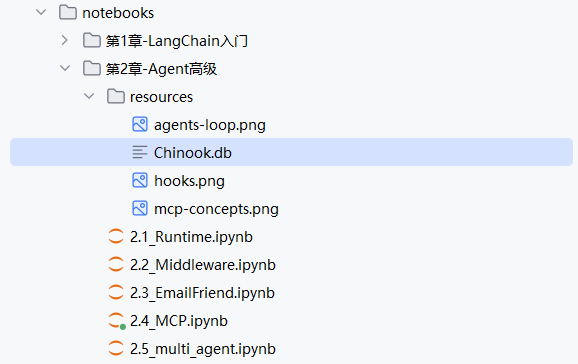

In [ ]:
db = SQLDatabase.from_uri("sqlite:///resources/Chinook.db")

@tool
def query_playlist_db(query: str) -> str:

    """Query the database for playlist information"""

    try:
        return db.run(query)
    except Exception as e:
        return f"Error querying database: {e}"

In [ ]:
# 测试，查询歌单数据
query_playlist_db.invoke({"query":"SELECT * FROM Playlist"})

如果能查询出下面数据，说明没问题：
```
"[(1, 'Music'), (2, 'Movies'), (3, 'TV Shows'), (4, 'Audiobooks'), (5, '90’s Music'), (6, 'Audiobooks'), (7, 'Movies'), (8, 'Music'), (9, 'Music Videos'), (10, 'TV Shows'), (11, 'Brazilian Music'), (12, 'Classical'), (13, 'Classical 101 - Deep Cuts'), (14, 'Classical 101 - Next Steps'), (15, 'Classical 101 - The Basics'), (16, 'Grunge'), (17, 'Heavy Metal Classic'), (18, 'On-The-Go 1')]"
```

In [ ]:
# Playlist agent
playlist_agent = create_agent(
    model="deepseek-chat",
    tools=[query_playlist_db],
    system_prompt="""
    You are a playlist specialist. Query the sql database and curate the perfect playlist for a wedding given a genre.
    Once you have your playlist, calculate the total duration and cost of the playlist, each song has an associated price.
    If you run into errors when querying the database, try to fix them by making changes to the query.
    Do not come back empty handed, keep trying to query the db until you find a list of songs.
    You may need to make multiple queries to iteratively find the best options.
    """
)

### 2.5 主Agent
最后，就是主Agent了，也是整个Agent的核心协调者。它负责与用户交互，收集婚礼信息，调用各个Subagent，筹备婚礼计划。
#### 2.5.1 定义state
首先，我们需要定义一个state，记录婚礼风格有关的信息，包括：
- 婚礼人数
- 音乐风格
- 出发地
- 婚礼举办地
```python
class WeddingState(AgentState):
    origin: str
    destination: str
    guest_count: str
    genre: str
```

#### 2.5.2 Tools
首先，要执行婚礼规划任务必须知道婚礼信息，也就是state中要记录的数据。AI通过与用户沟通可以获得这些信息，但是必须有一个tool负责更新state信息，当AI通过与用户聊天获取这些信息后，调用该tool更新到state中。
```
@tool
def update_state(origin: str, destination: str, guest_count: str, genre: str, runtime: ToolRuntime) -> str:
    """Update the state when you know all of the values: origin, destination, guest_count, genre"""
    return Command(update={
        "origin": origin,
        "destination": destination,
        "guest_count": guest_count,
        "genre": genre,
        "messages": [ToolMessage("Successfully updated state", tool_call_id=runtime.tool_call_id)]}
        )
```
接下来，按照Subagent模式，主Agent需要把Subagents当做一个个Tool来协调使用。所以，我们接下来就先定义3个Tool，分别对应3个Subagent.
这些tool读取state中的婚礼信息，然后调用对应的subagent，分别完成自己的任务。

In [ ]:
@tool
async def search_flights(runtime: ToolRuntime) -> str:
    """Travel agent searches for flights to the desired destination wedding location."""
    origin = runtime.state["origin"]
    destination = runtime.state["destination"]
    response = await travel_agent.ainvoke({"messages": [HumanMessage(content=f"Find flights from {origin} to {destination}")]})
    return response['messages'][-1].content

@tool
def search_venues(runtime: ToolRuntime) -> str:
    """Venue agent chooses the best venue for the given location and capacity."""
    destination = runtime.state["destination"]
    capacity = runtime.state["guest_count"]
    query = f"Find wedding venues in {destination} for {capacity} guests"
    response = venue_agent.invoke({"messages": [HumanMessage(content=query)]})
    return response['messages'][-1].content

@tool
def suggest_playlist(runtime: ToolRuntime) -> str:
    """Playlist agent curates the perfect playlist for the given genre."""
    genre = runtime.state["genre"]
    query = f"Find {genre} tracks for wedding playlist"
    response = playlist_agent.invoke({"messages": [HumanMessage(content=query)]})
    return response['messages'][-1].content

#### 2.5.3 Agent
接下来，就是创建主Agent了，把刚刚的4个Tools都注册给它，并给它设定核心协调者的任务。

In [ ]:
from langchain.agents import create_agent

coordinator = create_agent(
    model="deepseek-chat",
    tools=[search_flights, search_venues, suggest_playlist, update_state],
    state_schema=WeddingState,
    system_prompt="""
    You are a wedding coordinator. Delegate tasks to your specialists for flights, venues and playlists.
    First find all the information you need to update the state. Once that is done you can delegate the tasks.
    Once you have received their answers, coordinate the perfect wedding for me.
    """
)

In [ ]:
response = await coordinator.ainvoke(
    {
        "messages": [HumanMessage(content="我来自伦敦，我想在巴黎举办一场100人的婚礼，爵士风格的")],
    }
)

for message in response["messages"]:
    message.pretty_print()